# Gabor-Based Barcoding Index Development

## Objective

The exploratory analysis performed in Notebook 01 suggested that the barcoding phenomenon is more naturally characterized as a directional texture pattern than as a one-dimensional transmission signal.

Gabor filters provide a natural framework for quantifying such patterns because they respond selectively to structures with specific orientations and spatial frequencies.

The objective of this notebook is to investigate how Gabor filter parameters influence the measured response and to develop a reproducible Gabor-based barcoding index.

## Goals

This notebook will address the following questions:

1. Which spatial frequencies best capture the observed transmission columns?
2. Which filter orientations produce the strongest responses?
3. How sensitive are the resulting measurements to parameter choices?
4. Can multiple Gabor responses be combined into a single barcoding score?

Unlike Notebook 01, which focused on exploratory visualization, the emphasis here is on feature development and quantitative characterization.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d

from skimage import io
from skimage import color
from skimage import exposure

from skimage.filters import gabor

DATA_DIR = Path("../data/amd_best")

image_paths = sorted(DATA_DIR.glob("*.tif"))

print(image_paths)

def load_roi(path):

    img = io.imread(path)

    img_gray = color.rgb2gray(img)

    img_norm = exposure.rescale_intensity(
        img_gray,
        in_range="image",
        out_range=(0, 1)
    )

    roi = img_norm[
        180:350,
        :
    ]

    return roi

[PosixPath('../data/amd_best/amd_sample1.tif'), PosixPath('../data/amd_best/amd_sample2.tif'), PosixPath('../data/amd_best/amd_sample3.tif')]


We showed in the first notebook that Gabor filters respond. Now we want to show which spatial scale does this artifact contain the most energy so we test a grid of frequencies and look at both the scores and plots. We choose a minimum frequency of 0.02 with a stepsize of 0.02 until we hit 0.20. These are chosen since looking at the ROI, the image width is 768 pizels and most columns appear 10-20 pixels apart. 

In [2]:
frequencies = [
    0.02,
    0.04,
    0.06,
    0.08,
    0.10,
    0.15,
    0.20,
]

roi = load_roi(image_paths[0])

scores = []

for f in frequencies:

    real, imag = gabor(
        roi,
        frequency=f
    )

    score = np.mean(np.abs(real))

    scores.append(score)

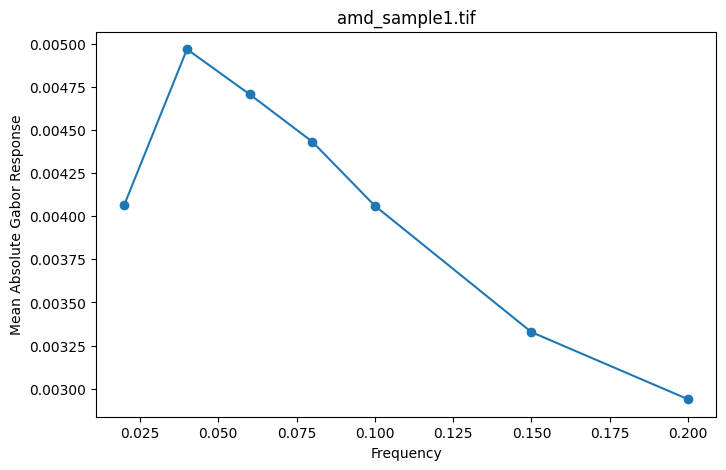

In [3]:
plt.figure(figsize=(8,5))

plt.plot(
    frequencies,
    scores,
    marker="o"
)

plt.xlabel("Frequency")
plt.ylabel("Mean Absolute Gabor Response")

plt.title(
    image_paths[0].name
)

plt.show()

## Frequency Sensitivity Analysis

The initial Gabor experiment used a single frequency selected from visual inspection of the images. To better understand the spatial scales associated with the barcoding phenomenon, the filter response was evaluated across a range of frequencies.

### Results

The Gabor response exhibits a clear maximum near a frequency of approximately

$$
f^* \approx 0.04.
$$

Response strength decreases steadily as the frequency increases beyond this value.

### Interpretation

This result suggests that the dominant texture associated with the barcoding pattern occurs at a specific spatial scale rather than being uniformly distributed across frequencies.

Lower frequencies correspond to broader image structures, whereas higher frequencies correspond to finer texture patterns. The observed response profile indicates that the transmission columns are relatively broad structures rather than fine-scale image texture.

### Characteristic Spatial Scale

For a Gabor filter, frequency and wavelength are related through

$$
\lambda
=
\frac{1}{f}.
$$

Using the frequency that produced the largest response,

$$
\lambda
=
\frac{1}{0.04}
=
25
\text{ pixels}.
$$

This provides an approximate estimate of the characteristic spacing of the transmission columns present in the ROI.

### Implications

The existence of a preferred frequency suggests that spatial scale may itself be an informative descriptor of the barcoding phenomenon.

Future analyses will investigate whether this dominant scale is consistent across images and whether frequency-specific responses improve quantification of barcoding severity.

Now we test orientation sensitivity.

In [4]:
# Fixed frequency identified from the first frequency scan
frequency = 0.04

# Candidate orientations in radians
thetas = [
    0,
    np.pi / 8,
    np.pi / 4,
    3 * np.pi / 8,
    np.pi / 2,
]

theta_labels = [
    "0",
    "pi/8",
    "pi/4",
    "3pi/8",
    "pi/2",
]

orientation_scores = []

for theta, label in zip(thetas, theta_labels):
    real, imag = gabor(
        roi,
        frequency=frequency,
        theta=theta
    )

    score = np.mean(np.abs(real))

    orientation_scores.append({
        "theta": label,
        "theta_radians": theta,
        "gabor_score": score
    })

orientation_df = pd.DataFrame(orientation_scores)
orientation_df

,theta,theta_radians,gabor_score
0,0,0.000000,0.004969
1,pi/8,0.392699,0.003759
2,pi/4,0.785398,0.002940
3,3pi/8,1.178097,0.004788
4,pi/2,1.570796,0.007839


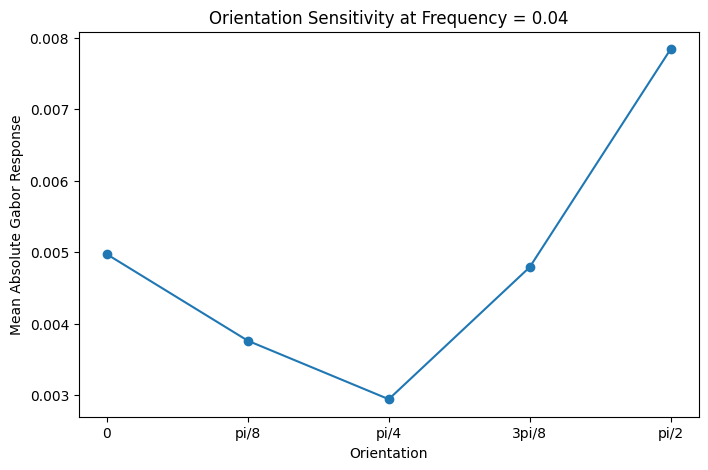

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    orientation_df["theta"],
    orientation_df["gabor_score"],
    marker="o"
)

plt.xlabel("Orientation")
plt.ylabel("Mean Absolute Gabor Response")
plt.title(f"Orientation Sensitivity at Frequency = {frequency}")

plt.show()

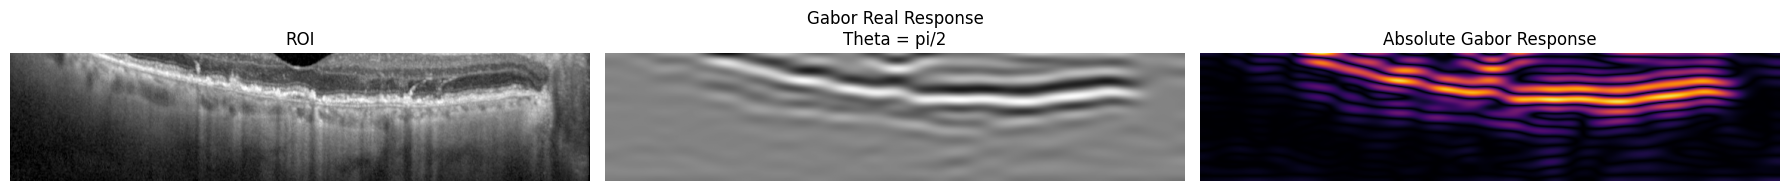

In [6]:
best_row = orientation_df.loc[orientation_df["gabor_score"].idxmax()]

best_theta = best_row["theta_radians"]

real_best, imag_best = gabor(
    roi,
    frequency=frequency,
    theta=best_theta
)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(roi, cmap="gray")
ax[0].set_title("ROI")
ax[0].axis("off")

ax[1].imshow(real_best, cmap="gray")
ax[1].set_title(f"Gabor Real Response\nTheta = {best_row['theta']}")
ax[1].axis("off")

ax[2].imshow(np.abs(real_best), cmap="inferno")
ax[2].set_title("Absolute Gabor Response")
ax[2].axis("off")

plt.tight_layout()
plt.show()

## Orientation Sensitivity Analysis

To determine whether the observed texture pattern exhibits a preferred direction, the Gabor response was evaluated across multiple filter orientations while holding the frequency fixed at the previously identified optimal value.

### Results

The largest response was obtained at

$$
\theta^*
=
\frac{\pi}{2},
$$

indicating a strong preference for a specific orientation.

The measured responses were:

| Orientation | Gabor Score |
|------------|------------:|
| $0$ | 0.00497 |
| $\pi/8$ | 0.00376 |
| $\pi/4$ | 0.00294 |
| $3\pi/8$ | 0.00479 |
| $\pi/2$ | 0.00784 |

### Interpretation

The response varies substantially across orientations, demonstrating that the detected texture is not isotropic.

Instead, the OCT image contains a dominant directional structure that is preferentially detected by filters aligned with the observed transmission pattern.

This finding is consistent with clinical descriptions of barcoding as a series of vertically oriented transmission columns extending into the choroid.

### Implications

The presence of a preferred orientation provides additional evidence that the barcoding phenomenon is best characterized as an oriented texture pattern rather than a simple intensity fluctuation.

Importantly, orientation-specific Gabor features appear to preserve information that is lost when the image is reduced to a one-dimensional transmission profile.

These results support the use of directional texture measures as candidate biomarkers for future barcoding quantification.

We now test for all images.

In [7]:
frequencies = [0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]

thetas = [
    0,
    np.pi / 8,
    np.pi / 4,
    3 * np.pi / 8,
    np.pi / 2,
]

theta_labels = ["0", "pi/8", "pi/4", "3pi/8", "pi/2"]

grid_results = []

for path in image_paths:
    roi = load_roi(path)

    for f in frequencies:
        for theta, theta_label in zip(thetas, theta_labels):
            real, imag = gabor(
                roi,
                frequency=f,
                theta=theta
            )

            score = np.mean(np.abs(real))

            grid_results.append({
                "image": path.name,
                "frequency": f,
                "theta": theta_label,
                "theta_radians": theta,
                "gabor_score": score
            })

gabor_grid_df = pd.DataFrame(grid_results)

gabor_grid_df.head()

,image,frequency,theta,theta_radians,gabor_score
0,amd_sample1.tif,0.02,0,0.000000,0.004067
1,amd_sample1.tif,0.02,pi/8,0.392699,0.003618
2,amd_sample1.tif,0.02,pi/4,0.785398,0.003996
3,amd_sample1.tif,0.02,3pi/8,1.178097,0.007470
4,amd_sample1.tif,0.02,pi/2,1.570796,0.014115


In [8]:
best_by_image = (
    gabor_grid_df
    .sort_values("gabor_score", ascending=False)
    .groupby("image")
    .head(1)
    .reset_index(drop=True)
)

best_by_image

,image,frequency,theta,theta_radians,gabor_score
0,amd_sample1.tif,0.02,pi/2,1.570796,0.014115
1,amd_sample3.tif,0.02,pi/2,1.570796,0.004837
2,amd_sample2.tif,0.06,0,0.000000,0.002806


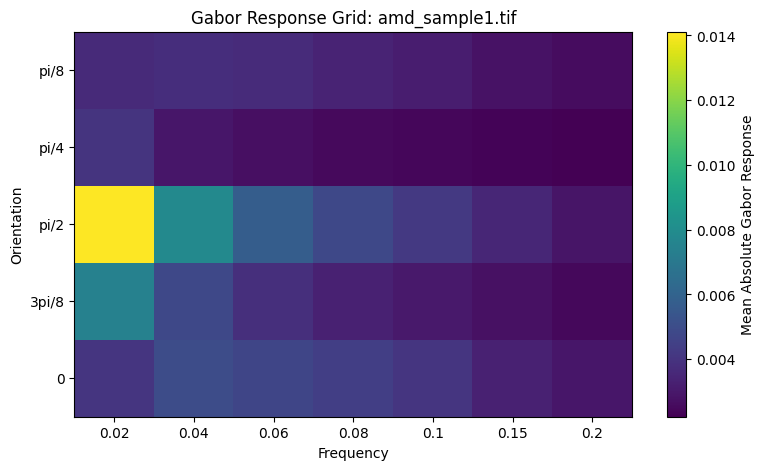

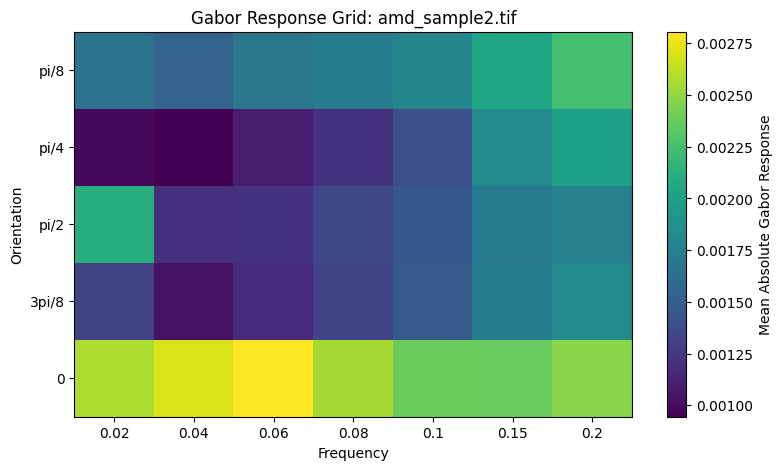

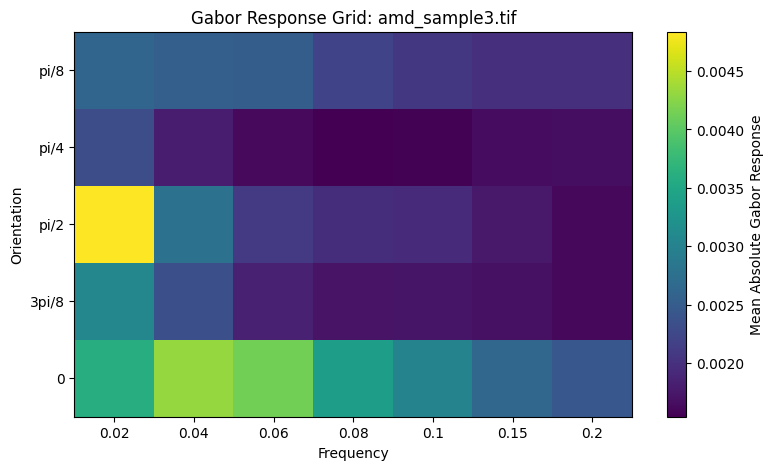

In [9]:
for image_name in gabor_grid_df["image"].unique():

    df_img = gabor_grid_df[gabor_grid_df["image"] == image_name]

    heatmap_data = df_img.pivot(
        index="theta",
        columns="frequency",
        values="gabor_score"
    )

    plt.figure(figsize=(9, 5))

    plt.imshow(
        heatmap_data,
        aspect="auto",
        origin="lower"
    )

    plt.colorbar(label="Mean Absolute Gabor Response")

    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )

    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )

    plt.xlabel("Frequency")
    plt.ylabel("Orientation")
    plt.title(f"Gabor Response Grid: {image_name}")

    plt.show()

In [10]:
best_configs = (
    gabor_grid_df
    .sort_values("gabor_score", ascending=False)
    .groupby("image")
    .head(5)
)

best_configs

,image,frequency,theta,theta_radians,gabor_score
4,amd_sample1.tif,0.02,pi/2,1.570796,0.014115
9,amd_sample1.tif,0.04,pi/2,1.570796,0.007839
3,amd_sample1.tif,0.02,3pi/8,1.178097,0.007470
14,amd_sample1.tif,0.06,pi/2,1.570796,0.005731
5,amd_sample1.tif,0.04,0,0.000000,0.004969
74,amd_sample3.tif,0.02,pi/2,1.570796,0.004837
75,amd_sample3.tif,0.04,0,0.000000,0.004316
80,amd_sample3.tif,0.06,0,0.000000,0.004141
70,amd_sample3.tif,0.02,0,0.000000,0.003596
85,amd_sample3.tif,0.08,0,0.000000,0.003371


In [11]:
best_by_image = (
    gabor_grid_df
    .sort_values("gabor_score", ascending=False)
    .groupby("image")
    .head(1)
    .reset_index(drop=True)
)

best_by_image

,image,frequency,theta,theta_radians,gabor_score
0,amd_sample1.tif,0.02,pi/2,1.570796,0.014115
1,amd_sample3.tif,0.02,pi/2,1.570796,0.004837
2,amd_sample2.tif,0.06,0,0.000000,0.002806


## Preliminary Parameter Optimization

The frequency-orientation grid reveals that Gabor responses are highly sensitive to both spatial scale and directional alignment.

Several notable patterns emerge:

- Strong responses are concentrated at low frequencies.
- The largest responses frequently occur near $\theta = \pi/2$, indicating a pronounced directional preference.
- Samples 1 and 3 exhibit highly similar response structures across the parameter grid.
- Sample 2 displays a somewhat different response pattern, suggesting either structural heterogeneity or sensitivity to local image characteristics.

These findings reinforce the hypothesis that the barcoding phenomenon is fundamentally an oriented texture pattern rather than a simple intensity fluctuation.

Importantly, the grid search demonstrates that parameter selection substantially affects measured response strength. Consequently, future barcoding indices should be based on systematically optimized or multi-scale Gabor features rather than a single arbitrarily chosen filter configuration.

Sample 2 still stands out. The filter may be partially responding to the retinal layering rather than transmission columns. We'll try summing the same grid search with a deeper ROI to see if the anomaly in sample 2 is driven by cropping.

In [13]:
roi_ranges = {
    "180:350": (180, 350),
    "200:360": (200, 360),
    "220:380": (220, 380),
    "240:400": (240, 400),
}

roi_sensitivity_results = []

for path in image_paths:
    img = io.imread(path)
    img_gray = color.rgb2gray(img)
    img_norm = exposure.rescale_intensity(
        img_gray,
        in_range="image",
        out_range=(0, 1)
    )

    for roi_label, (y0, y1) in roi_ranges.items():
        roi = img_norm[y0:y1, :]

        for f in frequencies:
            for theta, theta_label in zip(thetas, theta_labels):
                real, imag = gabor(
                    roi,
                    frequency=f,
                    theta=theta
                )

                score = np.mean(np.abs(real))

                roi_sensitivity_results.append({
                    "image": path.name,
                    "roi": roi_label,
                    "y0": y0,
                    "y1": y1,
                    "frequency": f,
                    "theta": theta_label,
                    "theta_radians": theta,
                    "gabor_score": score
                })

roi_sensitivity_df = pd.DataFrame(roi_sensitivity_results)

roi_sensitivity_df.head()

,image,roi,y0,y1,frequency,theta,theta_radians,gabor_score
0,amd_sample1.tif,180:350,180,350,0.02,0,0.000000,0.004067
1,amd_sample1.tif,180:350,180,350,0.02,pi/8,0.392699,0.003618
2,amd_sample1.tif,180:350,180,350,0.02,pi/4,0.785398,0.003996
3,amd_sample1.tif,180:350,180,350,0.02,3pi/8,1.178097,0.007470
4,amd_sample1.tif,180:350,180,350,0.02,pi/2,1.570796,0.014115


In [14]:
best_by_roi = (
    roi_sensitivity_df
    .sort_values("gabor_score", ascending=False)
    .groupby(["image", "roi"])
    .head(1)
    .reset_index(drop=True)
)

best_by_roi[
    [
        "image",
        "roi",
        "frequency",
        "theta",
        "gabor_score"
    ]
].sort_values(["image", "roi"])

,image,roi,frequency,theta,gabor_score
0,amd_sample1.tif,180:350,0.02,pi/2,0.014115
1,amd_sample1.tif,200:360,0.02,pi/2,0.012098
2,amd_sample1.tif,220:380,0.02,pi/2,0.009470
4,amd_sample1.tif,240:400,0.04,0,0.004455
7,amd_sample2.tif,180:350,0.06,0,0.002806
8,amd_sample2.tif,200:360,0.20,0,0.002467
9,amd_sample2.tif,220:380,0.20,0,0.002452
10,amd_sample2.tif,240:400,0.20,0,0.002437
3,amd_sample3.tif,180:350,0.02,pi/2,0.004837
5,amd_sample3.tif,200:360,0.04,0,0.003973


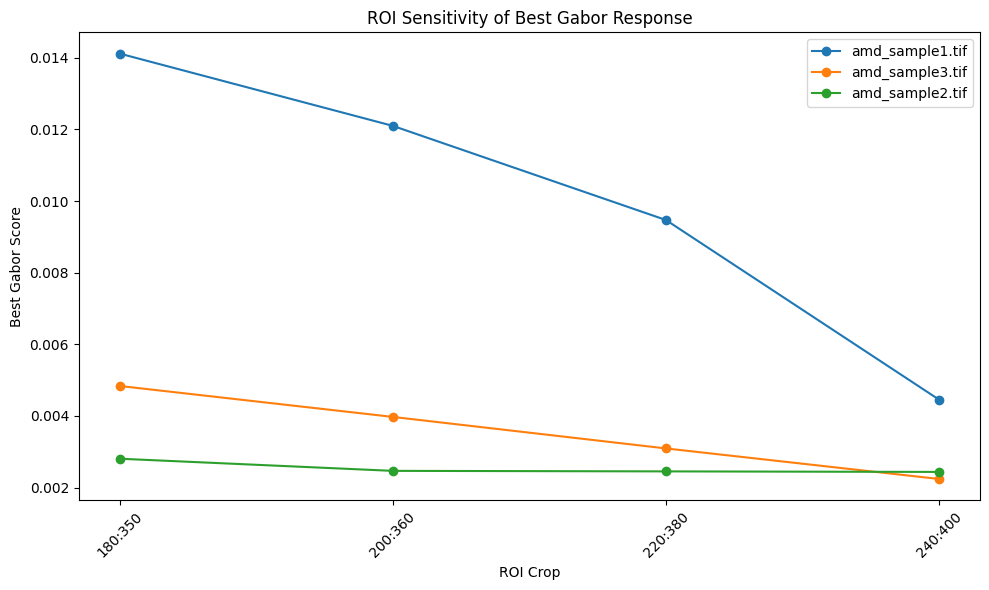

In [15]:
plt.figure(figsize=(10, 6))

for image_name in best_by_roi["image"].unique():
    df_img = best_by_roi[best_by_roi["image"] == image_name]

    plt.plot(
        df_img["roi"],
        df_img["gabor_score"],
        marker="o",
        label=image_name
    )

plt.xlabel("ROI Crop")
plt.ylabel("Best Gabor Score")
plt.title("ROI Sensitivity of Best Gabor Response")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Conclusions

This notebook investigated the use of Gabor filters for quantifying the OCT barcoding phenomenon.

Several important findings emerged:

- Gabor filters responded strongly to the visually apparent transmission columns.
- Response strength depended on both spatial frequency and orientation.
- Low-frequency filters generally produced the strongest responses.
- A preferred orientation was observed, supporting the hypothesis that barcoding is an oriented texture pattern.
- Samples 1 and 3 exhibited similar response structures, while Sample 2 behaved somewhat differently.
- ROI selection influenced response magnitude, although the overall behavior remained stable across reasonable crop choices.

Taken together, these results suggest that Gabor-based texture features provide a more informative representation of barcoding than one-dimensional transmission-profile statistics.

Future work will investigate alternative measures of directional structure, including structure tensor analysis and anisotropy metrics, and will explore combining multiple texture features into a unified barcoding index.

The Gabor score is sensitive to ROI selection in a predictable way. For samples 1 and 3, the score decreases as its picking up more pixels with less information. This means either 2 has weaker barcoding or is a different texture pattern than both 1 and 3